# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../../").resolve()
sys.path.append(str(module_path))

from src.data.simulation import generate_dict_of_combs
from src.data.exploration import *
from src.data.operation import import_non_spatial_data_frame
from src.utils.config import  base_pairs, third_values

In [2]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.parent.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

# Data loading

In [3]:
dict_of_combs = generate_dict_of_combs(base_pairs, third_values)
connection_link_var = repo_path_r_string + r'\data\simulations\experiment_001.sqlite'
dict_of_gdfs = {}

conn = sqlite3.connect(connection_link_var)

for name in dict_of_combs:

        df = import_non_spatial_data_frame(
            conn=conn,
            df_to_return_name=name
        )

        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df["x"], df["y"]),
            crs="EPSG:3857"
        )

        dict_of_gdfs[name] = gdf

conn.close()

In [4]:
df_results = pd.read_csv(repo_path_r_string + r'\results\data\experiment_001.csv')

In [5]:
df_results

,Unnamed: 0,effect_size,ring,true_effect,att_mSlearn,se_mSlearn,att_mCF,se_mCF,att_dCF,se_dCF,att_mDiD,se_mDiD
0,0,100.000000,treated_inner_ring,1.500000,1.159941,0.178888,1.720752,0.063438,1.679089,0.079442,1.685370,0.238042
1,1,100.000000,treated_outer_ring1,0.725939,0.258024,0.069869,0.764942,0.107312,0.835255,0.115293,0.819003,0.231775
2,2,100.000000,treated_outer_ring2,0.564862,0.535985,0.094476,0.807947,0.025616,0.508071,0.043763,0.759354,0.208357
3,3,100.000000,treated_outer_ring3,0.147708,0.057846,0.052953,0.089438,0.034025,0.345351,0.024087,0.130569,0.179064
4,4,100.000000,treated_outer_ring4,0.021262,0.085067,0.058451,0.123332,0.017513,0.244203,0.017396,0.132992,0.169956
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,15.384615,treated_inner_ring,1.500000,0.660123,0.138215,1.267180,0.085984,1.195152,0.084352,1.310661,0.247218
4996,4996,15.384615,treated_outer_ring1,1.036019,0.601779,0.121515,1.093935,0.104982,0.975866,0.082866,1.110259,0.239855
4997,4997,15.384615,treated_outer_ring2,0.614609,0.202950,0.083308,0.397926,0.054586,0.461284,0.032325,0.473658,0.216445
4998,4998,15.384615,treated_outer_ring3,0.159486,0.229346,0.048213,0.466182,0.025235,0.306393,0.018795,0.523824,0.186879


# Data transformation

In [6]:
model_dict = {
    "mSlearn": ("att_mSlearn", "se_mSlearn"),
    "mCF": ("att_mCF", "se_mCF"),
    "dCF": ("att_dCF", "se_dCF"),
    "mDiD": ("att_mDiD", "se_mDiD"),
}

df_sig, df_flagged = compute_significance_share(
    df=df_results,
    parameter_col="ring",
    model_dict=model_dict
)

df_sig2, df_flagged2 = compute_significance_share(
    df=df_results[df_results['ring'] == 'treated_inner_ring'],
    parameter_col="effect_size",
    model_dict=model_dict
)

df_sig3, df_flagged3 = compute_significance_share(
    df=df_results[df_results['ring'] == 'treated_outer_ring3'],
    parameter_col="effect_size",
    model_dict=model_dict
)

In [7]:
df_sig3

,effect_size,n,mSlearn_sig_share,mCF_sig_share,dCF_sig_share,mDiD_sig_share
0,15.384615,100,0.68,0.80,1.0,0.55
1,16.666667,100,0.72,0.76,1.0,0.57
2,18.181818,100,0.51,0.64,1.0,0.45
3,20.000000,100,0.72,0.76,1.0,0.44
4,22.222222,100,0.64,0.68,1.0,0.44
5,25.000000,100,0.61,0.74,1.0,0.47
6,28.571429,100,0.65,0.74,1.0,0.46
7,50.000000,100,0.59,0.75,1.0,0.46
8,66.666667,100,0.63,0.68,1.0,0.47
9,100.000000,100,0.62,0.75,1.0,0.44


In [8]:
df_sig

,ring,n,mSlearn_sig_share,mCF_sig_share,dCF_sig_share,mDiD_sig_share
0,treated_inner_ring,1000,1.000,1.000,1.0,1.000
1,treated_outer_ring1,1000,0.999,1.000,1.0,1.000
2,treated_outer_ring2,1000,0.980,0.990,1.0,0.970
3,treated_outer_ring3,1000,0.637,0.730,1.0,0.475
4,treated_outer_ring4,1000,0.339,0.456,1.0,0.174


# Visualizations

## Study setup

<Axes: >

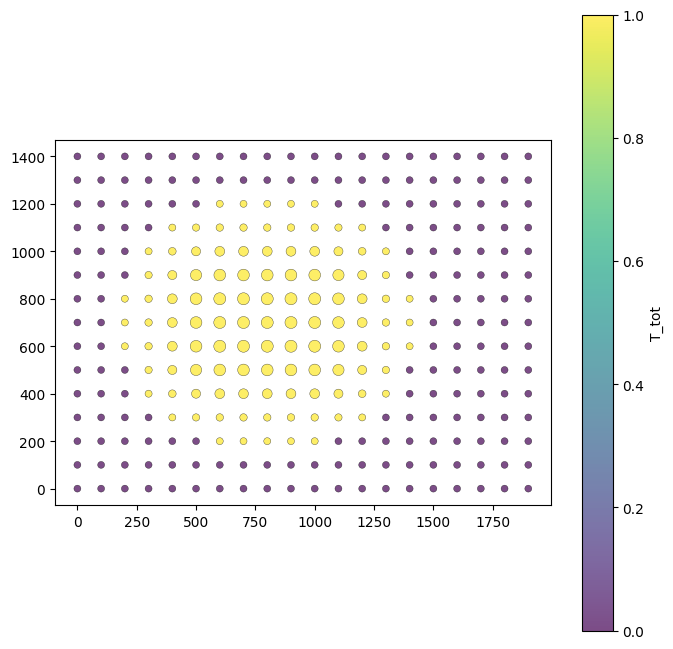

In [10]:
temp_gdf = dict_of_gdfs[list(dict_of_gdfs.keys())[0]].copy()
temp_gdf['spill2'] = temp_gdf['spill'] + 0.5
plot_gdf_points(temp_gdf, size_col='spill2',
    color_col='T_tot')

## Models empirical power

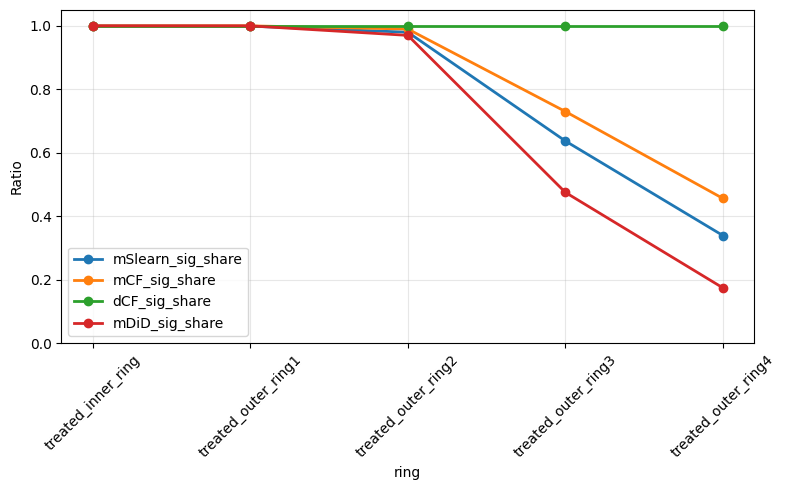

In [11]:
plot_ratios(
    df_sig,
    x_col="ring",
    y_cols=[
        "mSlearn_sig_share",
        "mCF_sig_share",
        "dCF_sig_share",
        "mDiD_sig_share"
    ]
)

## Models estimation accuracy (RMSE)

C:\Users\andre\Desktop\IDS\02_VS_code\03_comparing_causal_ML_models_with_spatial_effects\src\data\exploration.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


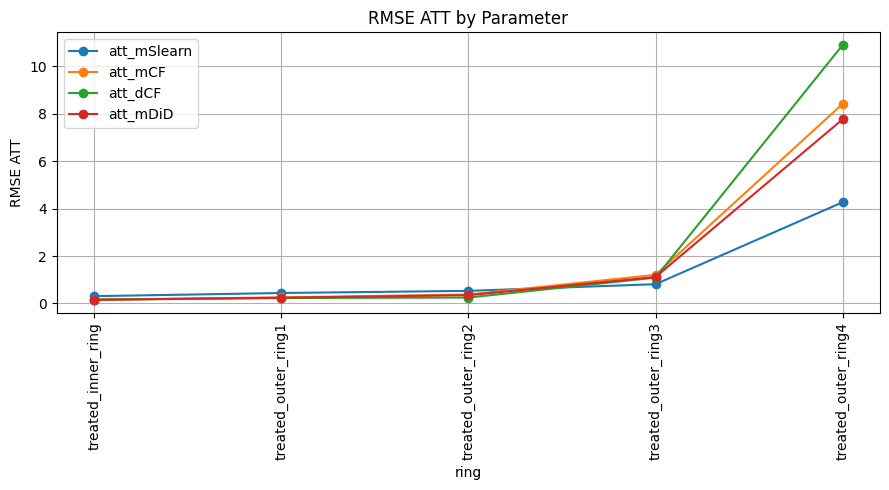

In [12]:
plot_rmse_att(
    df=df_results,
    parameter_col="ring",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD'],
    title_arg = "RMSE ATT by Parameter",
    y_axis_title = "RMSE ATT",
    rotate_x_labels=True
)

C:\Users\andre\Desktop\IDS\02_VS_code\03_comparing_causal_ML_models_with_spatial_effects\src\data\exploration.py:312: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


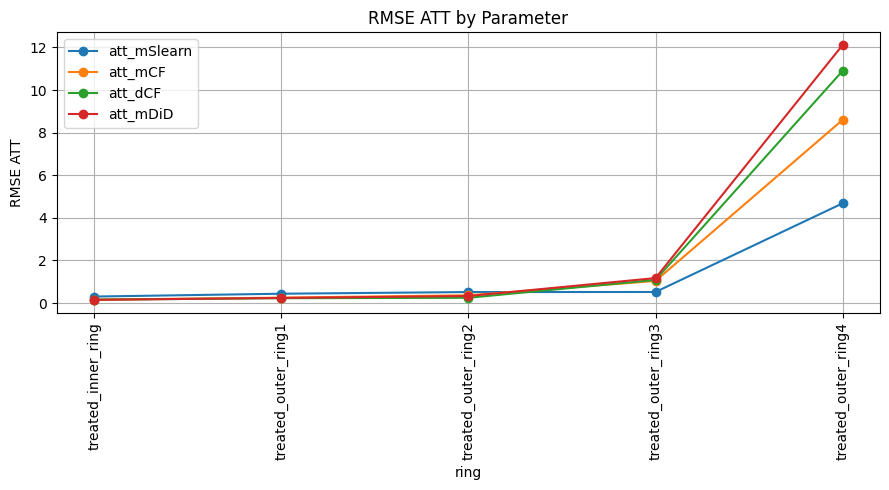

In [13]:
plot_rmse_att(
    df=df_flagged,
    parameter_col="ring",
    att_true_col="true_effect",
    model_cols=["att_mSlearn", "att_mCF", 'att_dCF', 'att_mDiD'],
    title_arg = "RMSE ATT by Parameter",
    y_axis_title = "RMSE ATT",
    rotate_x_labels=True
)